In [1]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

import torchaudio.transforms as T
import math   
from src.dataset import NSynth
import torch

mnist_datasets_path = r'C:\Users\Articuno\Desktop\TFG-info\data\mnist'
diff_mnist_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\diff_mnist.pth'

diff_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\diff.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# STFT transform
sample_rate = 16000
n_fft = 1500
hop_length = 250
win_length = n_fft
stft_transform = T.Spectrogram(
    n_fft=n_fft, win_length=win_length, hop_length=hop_length,
    power=2.0, onesided=False, center=False
).to(device)

In [3]:
# class Scheduler(nn.Module):
#     def __init__(self, num_epochs, beta_init=1e-4, beta_finish=0.02):
#         super().__init__()
#         self.beta = torch.linspace(beta_init, beta_finish, num_epochs, device=device)
#         alpha = 1 - self.beta
#         self.alpha = torch.cumprod(alpha, dim=0).requires_grad_(False)
        
#     def forward(self, t):
#         return self.beta[t], self.alpha[t], 

class Scheduler(nn.Module):
    def __init__(self, num_epochs, beta_init=1e-4, beta_finish=0.02):
        super().__init__()
        self.beta = torch.linspace(beta_init, beta_finish, num_epochs, device=device)
        self.alpha = 1 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def forward(self, t):
        return self.beta[t], self.alpha[t], self.alpha_bar[t]



In [4]:
class Diffuser(nn.Module):
    def __init__(self, model, scheduler):
        super().__init__()
        self.model = model
        self.scheduler = scheduler

    # x: input image, t: time step
    def forward(self, x, t):
        # e = torch.randn(1, 1, 32, 32) # ruido gaussiano
        e = torch.randn_like(x)  # ruido gaussiano mismo tamaño que x
        beta_t, alpha_t, alpha_bar_t = self.scheduler(t)
        # para que vaya con tensores
        # beta_t = beta_t.view(-1, 1, 1, 1)
        # alpha_t = alpha_t.view(-1, 1, 1, 1)
        # z = torch.sqrt(alpha_t) * x + torch.sqrt(beta_t) * e
    
        alpha_bar_t = alpha_bar_t.view(-1, 1, 1, 1)
        z = torch.sqrt(alpha_bar_t) * x + torch.sqrt(1 - alpha_bar_t) * e
        return z, e    

In [5]:
class Embeder(nn.Module):
    def __init__(self, num_epochs, embed_dim):
        super().__init__()
        position = torch.arange(num_epochs, device=device).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2, device=device).float() * -(math.log(10000.0) / embed_dim))
        embeddings = torch.zeros(num_epochs, embed_dim, device=device)
        embeddings[:, 0::2] = torch.sin(position * div)
        embeddings[:, 1::2] = torch.cos(position * div)
        self.embeddings = embeddings


    def forward(self, x, t):
        # t = t.long().view(-1) esto hace que t sea un tensor
        embeds = self.embeddings[t].to(x.device)
        return embeds[:, :, None, None]

In [6]:
class DummyLayer(nn.Module):
    def __init__(self, in_channels, out_channels, norm_groups):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(norm_groups, out_channels),
            nn.ReLU()
        )
        self.res_conv = nn.Conv2d(out_channels, out_channels, 3, padding=1)

    def forward(self, x, t_emb):
        out = self.conv(x)
        res = self.res_conv(out)
        return out, res


In [7]:
'''
    La vaina es la siguiente:
    - input_channels: canales de entrada (1 para escala de grises, 3 para RGB)
    - output_channels: canales de salida (1 para escala de grises, 3 para RGB)
    - layers: capas que van a hacer vainas a la entrada, la clase aun no esta implementada -> la entrada coincide con channels 0
        -> la salida coincide con channels 1
    - embedder: objeto que va a hacer el embedding del tiempo
    - channels: 
        0. canales de salida de la primera convolucion = canales de entrada a las layers
        1. canales de salida de las layers = canales de entrada de la convolucion de salida
'''
class DiffusionModel(nn.Module):
    def __init__(self, channels:list, norm_groups:int, layers:list[nn.Module], embedder:nn.Module, input_channels=1, output_channels=1):
        super().__init__()
        self.relu = nn.ReLU()
        self.channels = channels
        
        # aparentemente esto va de hacer redes convolucionales
        # self.conv_in = nn.Conv2d(input_channels, channels[0], kernel_size=3, padding=1),

        
        self.conv_in = nn.Sequential(
            nn.Conv2d(input_channels, channels[0], kernel_size=3, padding=1),
            nn.GroupNorm(norm_groups, channels[0]),
            nn.ReLU()
        )
        
        # self.conv_out = nn.Conv2d(channels[1], output_channels, kernel_size=3, padding=1)

        self.conv_out = nn.Sequential(
            nn.GroupNorm(norm_groups, channels[1] * 2),
            nn.ReLU(),
            nn.Conv2d(2*channels[1], output_channels, kernel_size=3, padding=1),
        )
        
        self.embeder = embedder
        self.layers = layers
        
    def forward(self, x, t):
        return self.forward_withres(x, t)
    
    def forward_nores(self, x, t):
        B, C, H, W = x.shape # batch, canales, altura, anchura
        x = self.conv_in(x)
        t_emb = self.embeder(x, t)
        for layer in self.layers:
            x, r = layer(x, t_emb)
        return self.conv_out(x)
        
    def forward_withres(self, x, t):
        B, C, H, W = x.shape # batch, canales, altura, anchura
        
        x = self.conv_in(x)
        t_emb = self.embeder(x, t)
        residuals = []
        it = 0
        for layer in self.layers:
            if it < len(self.layers) //2:
                x, r = layer(x, t_emb)
                residuals.append(r)
            else:
                x = torch.concat((layer(x, t_emb)[0], residuals.pop()), dim=1)
            it += 1
        # x = self.relu(x)
        return self.conv_out(x)
    
         

In [8]:
   
def train_old(input_size, epochs, batch_size=16, lr=1e-3):
    layers = [
        DummyLayer(64, 128, 8).to(device),
        DummyLayer(128, 128, 8).to(device),
    ]
    embedder = Embeder(num_epochs=epochs, embed_dim=128)
    model = DiffusionModel(
        channels=[64, 128],
        norm_groups=8,
        layers=layers,
        embedder=embedder,
        input_channels=1,
        output_channels=1        
    ).to(device)
    
    best_loss = 1
    
    # train_ds = FashionMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())

    train_loader = DataLoader(NSynth('training'), batch_size=batch_size, shuffle=True,  pin_memory=True)
    scheduler = Scheduler(num_epochs=epochs).to(device)
    diffuser = Diffuser(model, scheduler).to(device)
    
    optimizer = torch.optim.Adam(diffuser.parameters(), lr=lr)
    
    mse_loss = nn.MSELoss()
        
    for epoch in range(epochs):
        for wave, _, _, _ in train_loader:
            wave = wave.to(device)
            x = stft_transform(wave)
            
            x = x.to(device)
            batch_size = x.size(0)
            t = torch.randint(0, epochs, (batch_size,), device=device)

            z, e = diffuser(x, t)
            e_pred = model(z, t)

            loss = mse_loss(e_pred, e)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
            
        if loss.item() < best_loss:
            best_loss = loss.item()
            # torch.save(model.state_dict(), diff_model_path)
            print(f"Model saved at epoch {epoch} with loss {best_loss}")
    
    return model, scheduler


In [9]:
def train_minst(input_size, epochs, batch_size=16, lr=1e-3, path=mnist_datasets_path):
    layers = [
        DummyLayer(64, 128, 8).to(device),
        DummyLayer(128, 128, 8).to(device),
    ]
    embedder = Embeder(num_epochs=epochs, embed_dim=128)
    model = DiffusionModel(
        channels=[64, 128],
        norm_groups=8,
        layers=layers,
        embedder=embedder,
        input_channels=1,
        output_channels=1        
    ).to(device)
    
    best_loss = 1
    
    # train_ds = FashionMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())
    train_ds = FashionMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  pin_memory=True)
    scheduler = Scheduler(num_epochs=epochs).to(device)
    diffuser = Diffuser(model, scheduler).to(device)
    
    optimizer = torch.optim.Adam(diffuser.parameters(), lr=lr)
    
    mse_loss = nn.MSELoss()
        
    for epoch in range(epochs):
        for x, _ in train_loader:
            # wave = wave.to(device)
            # x = stft_transform(wave)
            
            x = x.to(device)
            batch_size = x.size(0)
            t = torch.randint(0, epochs, (batch_size,), device=device)

            z, e = diffuser(x, t)
            e_pred = model(z, t)

            loss = mse_loss(e_pred, e)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
            
        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save(model.state_dict(), diff_mnist_model_path)
            print(f"Model saved at epoch {epoch} with loss {best_loss}")
    
    return model, scheduler

In [10]:
   
def train(input_size, epochs=1000, batch_size=16, lr=1e-3, path=diff_model_path):
    layers = [
        DummyLayer(64, 128, 8).to(device),
        DummyLayer(128, 128, 8).to(device),
    ]
    embedder = Embeder(num_epochs=epochs, embed_dim=128)
    model = DiffusionModel(
        channels=[64, 128],
        norm_groups=8,
        layers=layers,
        embedder=embedder,
        input_channels=1,
        output_channels=1        
    ).to(device)
    
    best_loss = 1
    
    # train_ds = FashionMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())

    train_loader = DataLoader(NSynth('training'), batch_size=batch_size, shuffle=True,  pin_memory=True)
    scheduler = Scheduler(num_epochs=epochs).to(device)
    diffuser = Diffuser(model, scheduler).to(device)
    
    optimizer = torch.optim.Adam(diffuser.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler()
    mse_loss = nn.MSELoss()
        
    for epoch in range(epochs):
        

        for wave, _, _, _ in train_loader:
            wave = wave.to(device)

            # en principio autocast hacia que sea mas eficiente en memoria pero se ve que no lo suficiente
            with torch.cuda.amp.autocast():
                x = stft_transform(wave)
                batch_size = x.size(0)

                t = torch.randint(0, epochs, (batch_size,), device=device)

                z, e = diffuser(x, t)
                e_pred = model(z, t)

                loss = mse_loss(e_pred, e)

            optimizer.zero_grad()

            # backward con escala
            scaler.scale(loss).backward()

            # step escalado
            scaler.step(optimizer)

            # actualiza escala interna
            scaler.update()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
            
        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save(model.state_dict(), diff_model_path)
            print(f"Model saved at epoch {epoch} with loss {best_loss}")
    
    return model, scheduler


In [11]:
@torch.no_grad()
def sample_images_2(model, scheduler, num_images=4, image_size=(1, 28, 28)):
    model.eval()

    x = torch.randn(num_images, *image_size, device=device)
    T = scheduler.beta.size(0)

    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar

    for t in reversed(range(T)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

        # predicción de ruido
        e_pred = model(x, t_batch)
        
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        
        # beta_t = beta_t.view(1,1,1,1)
        # alpha_t = alpha_t.view(1,1,1,1)
        # alpha_bar_t = alpha_bar_t.view(1,1,1,1)


        # Coeficientes DDPM
        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

        mu = coef1 * (x - coef2 * e_pred)

        if t > 0:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mu + sigma_t * noise
        else:
            x = mu

    x = x.clamp(0, 1).cpu()

    # Mostrar imágenes
    fig, axes = plt.subplots(1, num_images, figsize=(num_images*2, 2))
    for i in range(num_images):
        axes[i].imshow(x[i, 0], cmap='gray')
        axes[i].axis('off')
    plt.show()

    return x


In [12]:

@torch.no_grad()
def sample_images(model, scheduler, num_images=4, image_size=(1, 28, 28)):
    model.eval()
    
    # Empieza desde ruido puro
    x = torch.randn(num_images, *image_size, device=device)
    T = scheduler.beta.size(0)
    
    for t in reversed(range(T)):
        t_batch = torch.tensor([t]*num_images, device=device)
        # predecir el ruido
        e_pred = model(x, t_batch)
        beta_t, alpha_t = scheduler(t_batch)
        beta_t = beta_t.view(-1, 1, 1, 1)
        alpha_t = alpha_t.view(-1, 1, 1, 1)
        
        # update x según DDPM simple (un paso de denoising)
        x = (x - torch.sqrt(beta_t) * e_pred) / torch.sqrt(alpha_t)
    
    # x ahora es la imagen generada
    x = x.clamp(0, 1).cpu()
    
    # Mostrar imágenes
    fig, axes = plt.subplots(1, num_images, figsize=(num_images*2, 2))
    for i in range(num_images):
        axes[i].imshow(x[i, 0], cmap='gray')
        axes[i].axis('off')
    plt.show()
    return x


In [13]:
# model, scheduler = train_minst(input_size=(1, 28, 28), epochs=400, batch_size=1024, lr=1e-3) # bastante bien

In [14]:
model, scheduler = train_minst(input_size=(1, 28, 28), epochs=1000, batch_size=2048, lr=1e-4) # bastante bien

Epoch 0, Loss: 0.5411466360092163
Model saved at epoch 0 with loss 0.5411466360092163
Model saved at epoch 1 with loss 0.30243104696273804
Model saved at epoch 2 with loss 0.22687029838562012
Model saved at epoch 3 with loss 0.192570298910141
Model saved at epoch 4 with loss 0.17656461894512177
Model saved at epoch 5 with loss 0.1664218008518219
Model saved at epoch 6 with loss 0.16524869203567505
Model saved at epoch 8 with loss 0.14031130075454712
Epoch 10, Loss: 0.1525956243276596
Model saved at epoch 12 with loss 0.12422559410333633
Model saved at epoch 15 with loss 0.12170299887657166
Model saved at epoch 16 with loss 0.11047883331775665
Epoch 20, Loss: 0.10759471356868744
Model saved at epoch 20 with loss 0.10759471356868744
Model saved at epoch 26 with loss 0.10293684154748917
Model saved at epoch 29 with loss 0.10200648009777069
Epoch 30, Loss: 0.10251669585704803
Model saved at epoch 32 with loss 0.09789734333753586
Model saved at epoch 33 with loss 0.09687734395265579
Model s

In [15]:
# layers = [
#     DummyLayer(64, 128, 8).to(device),
#     DummyLayer(128, 128, 8).to(device),
# ]
# embedder = Embeder(num_epochs=1000, embed_dim=128)
# scheduler = Scheduler(num_epochs=1000).to(device)

# model = DiffusionModel(
#     channels=[64, 128],
#     norm_groups=8,
#     layers=layers,
#     embedder=embedder,
#     input_channels=1,
#     output_channels=1        
# ).to(device)
# model.load_state_dict(torch.load(diff_model_path))

In [16]:
# sample_images(model, scheduler, num_images=10, image_size=(1, 28, 28))

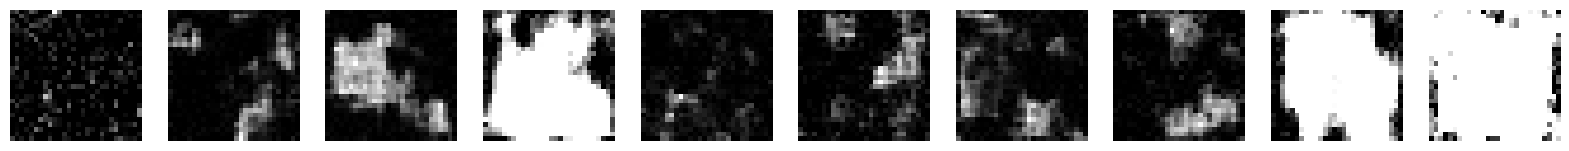

tensor([[[[1.3622e-01, 2.4210e-01, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 2.3112e-01,  ..., 8.2891e-02,
           0.0000e+00, 5.4770e-02],
          [1.6830e-01, 2.3335e-02, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 2.2869e-02, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 8.4651e-02, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 7.5001e-02],
          [1.9838e-01, 7.8574e-03, 8.8309e-02,  ..., 5.6078e-02,
           9.1736e-02, 0.0000e+00]]],


        [[[4.7582e-02, 7.7128e-02, 1.6150e-02,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [3.6206e-02, 6.6956e-02, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [1.6813e-02, 1.9749e-02, 3.5480e-02,  ..., 6.9266e-02,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 2.1109e-02, 0.0000e+00,  ..., 0.00

In [31]:
sample_images_2(model, scheduler, num_images=10, image_size=(1, 28, 28))

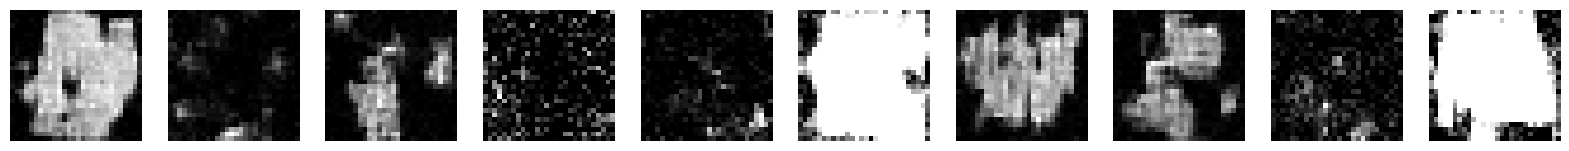

tensor([[[[0.0000e+00, 1.4854e-02, 2.1570e-02,  ..., 0.0000e+00,
           3.6095e-02, 0.0000e+00],
          [3.0173e-02, 0.0000e+00, 0.0000e+00,  ..., 1.0219e-01,
           6.3357e-02, 0.0000e+00],
          [2.0762e-02, 4.0406e-02, 0.0000e+00,  ..., 5.7376e-01,
           5.2928e-02, 1.2513e-01],
          ...,
          [1.3216e-02, 0.0000e+00, 1.5493e-02,  ..., 5.1238e-03,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 3.2950e-02, 0.0000e+00,  ..., 1.6534e-02,
           3.5376e-02, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]]],


        [[[0.0000e+00, 0.0000e+00, 4.1385e-02,  ..., 0.0000e+00,
           3.1525e-02, 0.0000e+00],
          [0.0000e+00, 5.6523e-02, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [1.1994e-01, 0.0000e+00, 2.0801e-02,  ..., 3.9192e-03,
           6.8563e-03, 1.9566e-02],
          ...,
          [4.0449e-02, 2.7467e-02, 1.2280e-02,  ..., 0.00

In [ ]:
# sample_images_2(model, scheduler, num_images=10, image_size=(1, 28, 28))

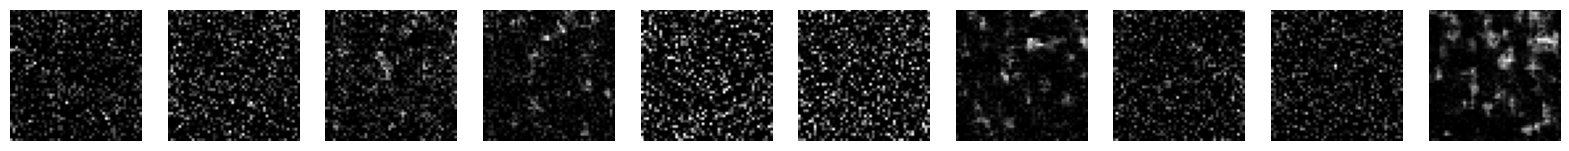

tensor([[[[0.0574, 0.2604, 0.0000,  ..., 0.3590, 0.0000, 0.0000],
          [0.0000, 0.0606, 0.0845,  ..., 0.2030, 0.1520, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.2194, 0.0000, 0.0029],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.2045, 0.0000, 0.0000],
          [0.6511, 0.0000, 0.4219,  ..., 0.0228, 0.0000, 0.0000]]],


        [[[0.1449, 0.0000, 0.6779,  ..., 0.3540, 0.0000, 0.0470],
          [0.0000, 0.1574, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.2300],
          ...,
          [0.0349, 0.0000, 0.0000,  ..., 0.0000, 0.4091, 0.0000],
          [0.0231, 0.0000, 0.0000,  ..., 0.4707, 0.0000, 0.0000],
          [0.0000, 0.5224, 0.2183,  ..., 0.0000, 0.0000, 0.2009]]],


        [[[0.0140, 0.1673, 0.0000,  ..., 0.0000, 0.0000, 0.0904],
          [0.0000, 0.1438, 0.0000,  ..., 0.0000, 0.2778, 0.0000],
          [0.0076, 0.0000, 0.0000,  ..

In [28]:
sample_images_2(model, scheduler, num_images=10, image_size=(1, 50, 50))

In [19]:
# model, scheduler = train(input_size=(1, 1500, 251), epochs=10, batch_size=128, lr=1e-3)
# sample_images(model, scheduler, num_images=1, image_size=(1, 480, 480))

In [20]:
# sample_images(model, scheduler, num_images=1, image_size=(1, 480, 480))